
# Direction O FINAL: Drug-specific adaptive feature fusion

Notebook cuối gom các kết quả từ các hướng A–N thành một framework tối ưu hiệu năng theo từng kháng sinh.

Ý tưởng chính:

> Không dùng một pipeline chung cho tất cả thuốc. Với mỗi thuốc, thử nhiều nhóm đặc trưng và nhiều mô hình, sau đó chọn cấu hình tốt nhất riêng cho thuốc đó.

Các module được thử:
1. `paper_ready50`
2. `accessory_chi2_200`
3. `accessory_chi2_500`
4. `paper_ready50_plus_chi2_200`
5. `paper_ready50_plus_chi2_500`
6. `ensemble_top_50`
7. `ensemble_top_500`
8. `accessory200_plus_functional_like`
9. `accessory200_plus_sample_graph`
10. `accessory200_plus_gene_graph_embedding`

In [ ]:
import os
import re
import json
import math
import shutil
import subprocess
import warnings
from pathlib import Path
from collections import Counter, defaultdict

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
from IPython.display import display

from sklearn.model_selection import train_test_split
from sklearn.feature_selection import chi2
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
)
from sklearn.decomposition import TruncatedSVD

import matplotlib.pyplot as plt

try:
    import xgboost as xgb
    HAS_XGB = True
except Exception:
    HAS_XGB = False

print("HAS_XGB:", HAS_XGB)


HAS_XGB: True


In [ ]:
REPO_URL = "https://github.com/347251369/Antimicrobial-resistance-prediction-in-Salmonella.git"

BASE_DIR = Path("/content/salmonella_direction_O_adaptive_fusion")
REPO_DIR = BASE_DIR / "Antimicrobial-resistance-prediction-in-Salmonella"
EXTRACT_DIR = BASE_DIR / "extracted"
OUTPUT_DIR = BASE_DIR / "outputs"

for d in [BASE_DIR, EXTRACT_DIR, OUTPUT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

DRUGS = ["AMP", "AUG", "AXO", "CHL", "FOX"]

N_REPEATS = 10
RANDOM_SEEDS = list(range(42, 42 + N_REPEATS))

K_SMALL = 50
K_MAIN = 200
K_LARGE = 500
MAX_CANDIDATE_FEATURES = 5000

MODEL_NAMES = ["LR_balanced", "RF_balanced"]
if HAS_XGB:
    MODEL_NAMES.append("XGB_weighted")

THRESHOLD_METRIC = "f1"

ENABLE_ENSEMBLE_SELECTOR = True
ENABLE_FUNCTIONAL_LIKE = True
ENABLE_SAMPLE_GRAPH = True
ENABLE_GENE_GRAPH_EMBEDDING = True

print("BASE_DIR:", BASE_DIR)
print("OUTPUT_DIR:", OUTPUT_DIR)
print("N_REPEATS:", N_REPEATS)
print("MODEL_NAMES:", MODEL_NAMES)


BASE_DIR: /content/salmonella_direction_O_adaptive_fusion
OUTPUT_DIR: /content/salmonella_direction_O_adaptive_fusion/outputs
N_REPEATS: 10
MODEL_NAMES: ['LR_balanced', 'RF_balanced', 'XGB_weighted']


In [ ]:

if not REPO_DIR.exists():
    !git clone --depth 1 https://github.com/347251369/Antimicrobial-resistance-prediction-in-Salmonella.git "{REPO_DIR}"
else:
    print("Repo đã tồn tại:", REPO_DIR)

!apt-get update -qq
!apt-get install -y unrar > /dev/null

accessory_extract_dir = EXTRACT_DIR / "accessory_gene"
accessory_extract_dir.mkdir(parents=True, exist_ok=True)

accessory_rar = REPO_DIR / "results" / "Roary" / "accessory gene existence matrix.rar"

if not any(accessory_extract_dir.glob("*")):
    if accessory_rar.exists():
        print("Giải nén:", accessory_rar)
        !unrar x -o+ "{accessory_rar}" "{accessory_extract_dir}/" > /dev/null
    else:
        print("Không thấy RAR trong repo, tải trực tiếp.")
        local_rar = BASE_DIR / "accessory_gene_existence_matrix.rar"
        url = "https://github.com/347251369/Antimicrobial-resistance-prediction-in-Salmonella/raw/main/results/Roary/accessory%20gene%20existence%20matrix.rar"
        !wget -q -O "{local_rar}" "{url}"
        !unrar x -o+ "{local_rar}" "{accessory_extract_dir}/" > /dev/null

print("File accessory:")
!find "{accessory_extract_dir}" -maxdepth 2 -type f | head -20


Cloning into '/content/salmonella_direction_O_adaptive_fusion/Antimicrobial-resistance-prediction-in-Salmonella'...
remote: Enumerating objects: 79, done.
remote: Counting objects: 100% (79/79), done.
remote: Compressing objects: 100% (53/53), done.
remote: Total 79 (delta 33), reused 54 (delta 25), pack-reused 0 (from 0)
Receiving objects: 100% (79/79), 2.95 MiB | 18.86 MiB/s, done.
Resolving deltas: 100% (33/33), done.
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Giải nén: /content/salmonella_direction_O_adaptive_fusion/Antimicrobial-resistance-prediction-in-Salmonella/results/Roary/accessory gene existence matrix.rar
File accessory:
/content/salmonella_direction_O_adaptive_fusion/extracted/accessory_gene/accessory gene existence matrix.csv


In [ ]:

def list_files(root, suffixes=None):
    root = Path(root)
    files = []
    for p in root.rglob("*"):
        if p.is_file():
            if suffixes is None or p.suffix.lower() in suffixes:
                files.append(p)
    return files

def find_largest_table(root):
    candidates = list_files(root, suffixes=[".csv", ".tsv", ".txt", ".xlsx", ".xls"])
    if not candidates:
        raise FileNotFoundError(f"Không tìm thấy bảng trong {root}")
    candidates = sorted(candidates, key=lambda p: p.stat().st_size, reverse=True)
    print("Các bảng tìm thấy:")
    for p in candidates[:10]:
        print(" -", p.name, round(p.stat().st_size / 1024 / 1024, 2), "MB")
    return candidates[0]

def read_table_flexible(path):
    path = Path(path)
    if path.suffix.lower() == ".csv":
        return pd.read_csv(path)
    if path.suffix.lower() in [".tsv", ".txt"]:
        df = pd.read_csv(path, sep="\t")
        if df.shape[1] == 1:
            df = pd.read_csv(path)
        return df
    if path.suffix.lower() in [".xlsx", ".xls"]:
        return pd.read_excel(path)
    raise ValueError(path)

def make_sample_index(n):
    return pd.Index([f"sample_{i}" for i in range(n)], name="sample_id")

def coerce_numeric_features(df):
    out = df.copy()
    drop_cols = []
    for col in list(out.columns):
        if out[col].dtype == "object":
            converted = pd.to_numeric(out[col], errors="coerce")
            if converted.notna().mean() > 0.95:
                out[col] = converted.fillna(0)
            else:
                drop_cols.append(col)
    if drop_cols:
        out = out.drop(columns=drop_cols)
    out = out.fillna(0)
    for col in out.columns:
        vals = pd.unique(out[col])
        if len(vals) <= 3:
            try:
                out[col] = out[col].astype(np.int8)
            except Exception:
                pass
    return out

def parse_label_series(y_raw):
    y = y_raw.copy()
    if isinstance(y, pd.DataFrame):
        candidates = [c for c in y.columns if any(k in c.lower() for k in ["label", "phenotype", "result", "concl"])]
        col = candidates[0] if candidates else y.columns[-1]
        y = y[col]
    y = y.replace({
        "S": 0, "I": 0, "R": 1,
        "s": 0, "i": 0, "r": 1,
        "Susceptible": 0, "Intermediate": 0, "Resistant": 1,
        "susceptible": 0, "intermediate": 0, "resistant": 1
    })
    y = pd.to_numeric(y, errors="coerce")
    return y

def find_drug_label_file(drug):
    drug_dir = REPO_DIR / "data" / "csv" / drug
    exact = drug_dir / f"{drug}_label.csv"
    if exact.exists():
        return exact
    candidates = list(drug_dir.glob("*label*.csv"))
    if candidates:
        return candidates[0]
    raise FileNotFoundError(f"Không tìm thấy label csv cho {drug} trong {drug_dir}")

def load_ready_gene_and_label(drug):
    drug_dir = REPO_DIR / "data" / "csv" / drug
    gene_path = drug_dir / "gene.csv"
    label_path = find_drug_label_file(drug)

    X = pd.read_csv(gene_path)
    X = coerce_numeric_features(X)

    ydf = pd.read_csv(label_path)
    y = parse_label_series(ydf)

    mask = y.notna()
    X = X.loc[mask.values].reset_index(drop=True)
    y = y.loc[mask].reset_index(drop=True).astype(int)

    idx = make_sample_index(len(y))
    X.index = idx
    y.index = idx

    return X, y, gene_path, label_path

def prepare_model_matrix(X_train, X_val, X_test):
    X_train = pd.DataFrame(X_train).copy()
    X_val = pd.DataFrame(X_val).copy()
    X_test = pd.DataFrame(X_test).copy()

    X_train = X_train.apply(pd.to_numeric, errors="coerce").fillna(0)
    X_val = X_val.apply(pd.to_numeric, errors="coerce").fillna(0)
    X_test = X_test.apply(pd.to_numeric, errors="coerce").fillna(0)

    cols = [f"f_{i}" for i in range(X_train.shape[1])]
    X_train.columns = cols
    X_val.columns = cols
    X_test.columns = cols
    return X_train, X_val, X_test


In [ ]:

def safe_scores(y_true, y_pred, y_prob):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "auroc": roc_auc_score(y_true, y_prob) if len(np.unique(y_true)) > 1 else np.nan,
        "auprc": average_precision_score(y_true, y_prob) if len(np.unique(y_true)) > 1 else np.nan,
    }

def choose_threshold(y_val, prob_val, metric="f1"):
    thresholds = np.linspace(0.05, 0.95, 91)
    best_t, best_score = 0.5, -1
    for t in thresholds:
        pred = (prob_val >= t).astype(int)
        if metric == "balanced_accuracy":
            score = balanced_accuracy_score(y_val, pred)
        else:
            score = f1_score(y_val, pred, zero_division=0)
        if score > best_score:
            best_score = score
            best_t = t
    return float(best_t), float(best_score)

def make_model(model_name, y_train, seed=42):
    if model_name == "LR_balanced":
        return LogisticRegression(max_iter=5000, class_weight="balanced", solver="lbfgs", random_state=seed)
    if model_name == "RF_balanced":
        return RandomForestClassifier(
            n_estimators=300,
            min_samples_leaf=2,
            class_weight="balanced_subsample",
            random_state=seed,
            n_jobs=-1
        )
    if model_name == "XGB_weighted":
        if not HAS_XGB:
            raise RuntimeError("XGBoost không có")
        pos = max(int(y_train.sum()), 1)
        neg = max(int((y_train == 0).sum()), 1)
        return xgb.XGBClassifier(
            n_estimators=250,
            max_depth=4,
            learning_rate=0.04,
            subsample=0.85,
            colsample_bytree=0.85,
            eval_metric="logloss",
            scale_pos_weight=neg / pos,
            random_state=seed,
            n_jobs=-1
        )
    raise ValueError(model_name)

def fit_predict_with_threshold(model, X_train, y_train, X_val, y_val, X_test, y_test):
    X_train, X_val, X_test = prepare_model_matrix(X_train, X_val, X_test)

    model.fit(X_train, y_train)
    prob_val = model.predict_proba(X_val)[:, 1] if hasattr(model, "predict_proba") else model.decision_function(X_val)
    prob_test = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else model.decision_function(X_test)

    threshold, val_metric = choose_threshold(y_val, prob_val, metric=THRESHOLD_METRIC)
    pred_test = (prob_test >= threshold).astype(int)

    scores = safe_scores(y_test, pred_test, prob_test)
    scores["threshold"] = threshold
    scores["val_threshold_metric"] = val_metric
    return scores


In [ ]:

ready_data = {}
stats_rows = []
for drug in DRUGS:
    Xr, yr, gp, lp = load_ready_gene_and_label(drug)
    ready_data[drug] = {"X": Xr, "y": yr, "gene_path": gp, "label_path": lp}
    stats_rows.append({
        "drug": drug,
        "gene_shape": str(Xr.shape),
        "label_file": str(lp.relative_to(REPO_DIR)),
        "n_samples": len(yr),
        "n_resistant": int(yr.sum()),
        "n_non_resistant": int((yr == 0).sum()),
        "resistant_rate": float(yr.mean())
    })

stats_df = pd.DataFrame(stats_rows)
display(stats_df)
stats_df.to_csv(OUTPUT_DIR / "direction_O_dataset_stats.csv", index=False)

accessory_path = find_largest_table(accessory_extract_dir)
X_accessory_raw = read_table_flexible(accessory_path)
X_accessory = coerce_numeric_features(X_accessory_raw)

if X_accessory.shape[0] == len(next(iter(ready_data.values()))["y"]):
    X_accessory.index = make_sample_index(X_accessory.shape[0])
else:
    raise ValueError(f"Accessory rows {X_accessory.shape[0]} không khớp label rows.")

print("X_accessory:", X_accessory.shape)
print("Memory MB:", round(X_accessory.memory_usage(deep=True).sum() / 1024 / 1024, 2))
display(X_accessory.iloc[:3, :5])


,drug,gene_shape,label_file,n_samples,n_resistant,n_non_resistant,resistant_rate
0,AMP,"(1167, 50)",data/csv/AMP/AMP_label.csv,1167,199,968,0.170523
1,AUG,"(1167, 50)",data/csv/AUG/AUG_label.csv,1167,139,1028,0.119109
2,AXO,"(1167, 50)",data/csv/AXO/AXO_label.csv,1167,71,1096,0.060840
3,CHL,"(1167, 50)",data/csv/CHL/CHL_label.csv,1167,126,1041,0.107969
4,FOX,"(1167, 50)",data/csv/FOX/FOX_label.csv,1167,71,1096,0.060840


Các bảng tìm thấy:
 - accessory gene existence matrix.csv 40.59 MB
X_accessory: (1167, 18125)
Memory MB: 20.24


,ldtD,golT,GXP82_000609,D1K42_06100,astB
sample_id,,,,,
sample_0,1,1,1,1,1
sample_1,1,1,1,1,1
sample_2,1,1,1,1,1


In [ ]:


# Feature selection

def top_variance_candidates(X_train, max_features=5000):
    if X_train.shape[1] <= max_features:
        return list(X_train.columns)
    variances = X_train.var(axis=0)
    return list(variances.sort_values(ascending=False).head(max_features).index)

def select_chi2_topk(X_train, y_train, k=200, max_candidates=5000):
    candidate_cols = top_variance_candidates(X_train, max_candidates)
    X_cand = X_train[candidate_cols]
    scores, _ = chi2(X_cand.clip(lower=0), y_train)
    s = pd.Series(scores, index=candidate_cols).replace([np.inf, -np.inf], np.nan).fillna(0)
    return list(s.sort_values(ascending=False).head(k).index)

def normalize_score_series(s):
    s = s.astype(float).replace([np.inf, -np.inf], np.nan).fillna(0)
    if s.max() == s.min():
        return pd.Series(np.zeros(len(s)), index=s.index)
    return (s - s.min()) / (s.max() - s.min())

def score_l1_logistic(X_train, y_train, seed=42):
    model = LogisticRegression(
        penalty="l1",
        solver="liblinear",
        class_weight="balanced",
        max_iter=1000,
        random_state=seed
    )
    model.fit(X_train, y_train)
    return pd.Series(np.abs(model.coef_[0]), index=X_train.columns).fillna(0)

def score_rf_importance(X_train, y_train, seed=42):
    model = RandomForestClassifier(
        n_estimators=120,
        min_samples_leaf=2,
        class_weight="balanced_subsample",
        random_state=seed,
        n_jobs=-1
    )
    model.fit(X_train, y_train)
    return pd.Series(model.feature_importances_, index=X_train.columns).fillna(0)

def select_ensemble_topk(X_train, y_train, k=200, seed=42, max_candidates=5000):
    candidate_cols = top_variance_candidates(X_train, max_candidates)
    X_cand = X_train[candidate_cols]

    scores = []

    chi_scores, _ = chi2(X_cand.clip(lower=0), y_train)
    scores.append(normalize_score_series(pd.Series(chi_scores, index=candidate_cols)))

    try:
        scores.append(normalize_score_series(score_l1_logistic(X_cand, y_train, seed)))
    except Exception as e:
        print("Bỏ qua L1 selector:", e)

    try:
        scores.append(normalize_score_series(score_rf_importance(X_cand, y_train, seed)))
    except Exception as e:
        print("Bỏ qua RF selector:", e)

    ensemble = pd.concat(scores, axis=1).mean(axis=1)
    return list(ensemble.sort_values(ascending=False).head(k).index)


In [ ]:

# Functional-like / graph feature functions

FUNCTIONAL_GROUPS = {
    "beta_lactamase": ["cmy", "tem", "oxa", "ctx", "shv", "bla", "beta", "lactamase"],
    "efflux_transporter": ["flor", "suge", "tolc", "mdfa", "acr", "efflux", "transporter", "pump"],
    "sulfonamide": ["sul1", "sul2", "sul3", "sul"],
    "metal_stress": ["mera", "mert", "mer", "ars", "metal", "copper", "silver"],
    "mobile_element": ["transposase", "integrase", "plasmid", "insertion", "tnp"],
    "phage_related": ["phage", "tail", "capsid", "bacteriophage"],
}

def make_functional_like_features(X_df):
    X_df = pd.DataFrame(X_df)
    cols_lower = {c: str(c).lower() for c in X_df.columns}
    out = {}
    for group, keywords in FUNCTIONAL_GROUPS.items():
        matched = [c for c, cl in cols_lower.items() if any(k in cl for k in keywords)]
        if matched:
            counts = X_df[matched].sum(axis=1).values
            out[f"func_{group}_count"] = counts
            out[f"func_{group}_presence"] = (counts > 0).astype(int)
        else:
            out[f"func_{group}_count"] = np.zeros(X_df.shape[0])
            out[f"func_{group}_presence"] = np.zeros(X_df.shape[0])
    return pd.DataFrame(out, index=X_df.index)

def binary_jaccard_similarity(A, B):
    A = np.asarray(A, dtype=np.float32)
    B = np.asarray(B, dtype=np.float32)
    inter = A @ B.T
    sumA = A.sum(axis=1, keepdims=True)
    sumB = B.sum(axis=1, keepdims=True).T
    union = sumA + sumB - inter
    return inter / np.maximum(union, 1e-8)

def make_sample_graph_features(X_train_sel, y_train, X_query_sel, is_train_query=False, top_k=15):
    sim = binary_jaccard_similarity(X_query_sel.values, X_train_sel.values)
    ytr = np.asarray(y_train).astype(float)

    if is_train_query and sim.shape[0] == sim.shape[1]:
        np.fill_diagonal(sim, -1.0)

    feats = []
    for i in range(sim.shape[0]):
        row = sim[i].copy()
        idx = np.argsort(row)[::-1][:top_k]
        sims = row[idx]
        labels = ytr[idx]
        valid = sims >= 0
        sims = sims[valid]
        labels = labels[valid]

        if len(sims) == 0:
            feats.append([0, 0, 0, 0, 0, 0, 0])
            continue

        weights = np.maximum(sims, 0)
        weighted_rate = float((weights * labels).sum() / weights.sum()) if weights.sum() > 0 else float(labels.mean())
        resistant_sims = row[ytr == 1]
        sensitive_sims = row[ytr == 0]

        feats.append([
            float(labels.mean()),
            weighted_rate,
            float(np.max(sims)),
            float(np.mean(sims)),
            float(np.max(resistant_sims)) if len(resistant_sims) else 0.0,
            float(np.max(sensitive_sims)) if len(sensitive_sims) else 0.0,
            float((labels == 1).sum()),
        ])

    cols = [
        "neighbor_resistant_rate",
        "weighted_neighbor_resistant_rate",
        "max_neighbor_similarity",
        "mean_topk_similarity",
        "max_similarity_to_resistant_train",
        "max_similarity_to_sensitive_train",
        "topk_resistant_count",
    ]
    return pd.DataFrame(feats, index=X_query_sel.index, columns=cols)

def build_gene_cooccurrence_adjacency(X_train_sel, top_edges_per_gene=8):
    X = X_train_sel.astype(float)
    corr = np.corrcoef(X.values, rowvar=False)
    corr = np.nan_to_num(corr, nan=0.0, posinf=0.0, neginf=0.0)
    np.fill_diagonal(corr, 0.0)
    corr = np.abs(corr)

    A = np.zeros_like(corr, dtype=np.float32)
    for i in range(corr.shape[0]):
        idx = np.argsort(corr[i])[::-1][:top_edges_per_gene]
        A[i, idx] = corr[i, idx]
    A = np.maximum(A, A.T)
    return A

def fit_gene_graph_embedding(X_train_sel, n_components=16):
    A = build_gene_cooccurrence_adjacency(X_train_sel, top_edges_per_gene=8)
    n_components = min(n_components, max(2, A.shape[0] - 1))
    svd = TruncatedSVD(n_components=n_components, random_state=42)
    gene_emb = svd.fit_transform(A)
    return gene_emb

def transform_samples_with_gene_embedding(X_sel, gene_emb):
    Xv = X_sel.values.astype(float)
    counts = np.maximum(Xv.sum(axis=1, keepdims=True), 1.0)
    emb_mean = (Xv @ gene_emb) / counts
    gene_count = Xv.sum(axis=1, keepdims=True)
    out = np.hstack([emb_mean, gene_count])
    cols = [f"gene_graph_emb_{i}" for i in range(emb_mean.shape[1])] + ["selected_gene_count"]
    return pd.DataFrame(out, index=X_sel.index, columns=cols)


In [ ]:

# Tạo feature modules cho một split

def concat_features(*dfs):
    return pd.concat([pd.DataFrame(df).reset_index(drop=True) for df in dfs], axis=1)

def make_feature_modules_for_split(drug, X_train, X_val, X_test, y_train, seed):
    modules = {}

    X_ready_all = ready_data[drug]["X"]
    Rtr = X_ready_all.loc[X_train.index]
    Rva = X_ready_all.loc[X_val.index]
    Rte = X_ready_all.loc[X_test.index]
    modules["paper_ready50"] = (Rtr, Rva, Rte)

    chi2_200 = select_chi2_topk(X_train, y_train, k=K_MAIN, max_candidates=MAX_CANDIDATE_FEATURES)
    chi2_500 = select_chi2_topk(X_train, y_train, k=K_LARGE, max_candidates=MAX_CANDIDATE_FEATURES)

    A200tr, A200va, A200te = X_train[chi2_200], X_val[chi2_200], X_test[chi2_200]
    A500tr, A500va, A500te = X_train[chi2_500], X_val[chi2_500], X_test[chi2_500]

    modules["accessory_chi2_200"] = (A200tr, A200va, A200te)
    modules["accessory_chi2_500"] = (A500tr, A500va, A500te)

    modules["paper_ready50_plus_chi2_200"] = (
        concat_features(Rtr, A200tr),
        concat_features(Rva, A200va),
        concat_features(Rte, A200te),
    )
    modules["paper_ready50_plus_chi2_500"] = (
        concat_features(Rtr, A500tr),
        concat_features(Rva, A500va),
        concat_features(Rte, A500te),
    )

    if ENABLE_ENSEMBLE_SELECTOR:
        ens_50 = select_ensemble_topk(X_train, y_train, k=K_SMALL, seed=seed, max_candidates=MAX_CANDIDATE_FEATURES)
        ens_500 = select_ensemble_topk(X_train, y_train, k=K_LARGE, seed=seed, max_candidates=MAX_CANDIDATE_FEATURES)
        modules["ensemble_top_50"] = (X_train[ens_50], X_val[ens_50], X_test[ens_50])
        modules["ensemble_top_500"] = (X_train[ens_500], X_val[ens_500], X_test[ens_500])

    if ENABLE_FUNCTIONAL_LIKE:
        Ftr = make_functional_like_features(A200tr)
        Fva = make_functional_like_features(A200va)
        Fte = make_functional_like_features(A200te)
        modules["accessory200_plus_functional_like"] = (
            concat_features(A200tr, Ftr),
            concat_features(A200va, Fva),
            concat_features(A200te, Fte),
        )

    if ENABLE_SAMPLE_GRAPH:
        Gtr = make_sample_graph_features(A200tr, y_train, A200tr, is_train_query=True, top_k=15)
        Gva = make_sample_graph_features(A200tr, y_train, A200va, is_train_query=False, top_k=15)
        Gte = make_sample_graph_features(A200tr, y_train, A200te, is_train_query=False, top_k=15)
        modules["accessory200_plus_sample_graph"] = (
            concat_features(A200tr, Gtr),
            concat_features(A200va, Gva),
            concat_features(A200te, Gte),
        )
        modules["sample_graph_only"] = (Gtr, Gva, Gte)

    if ENABLE_GENE_GRAPH_EMBEDDING:
        gene_emb = fit_gene_graph_embedding(A200tr, n_components=16)
        Etr = transform_samples_with_gene_embedding(A200tr, gene_emb)
        Eva = transform_samples_with_gene_embedding(A200va, gene_emb)
        Ete = transform_samples_with_gene_embedding(A200te, gene_emb)
        modules["accessory200_plus_gene_graph_embedding"] = (
            concat_features(A200tr, Etr),
            concat_features(A200va, Eva),
            concat_features(A200te, Ete),
        )
        modules["gene_graph_embedding_only"] = (Etr, Eva, Ete)

    return modules


In [ ]:

all_rows = []

def evaluate_drug_direction_O(drug):
    y_all = ready_data[drug]["y"]
    X_all = X_accessory.loc[y_all.index]
    rows = []

    for seed in RANDOM_SEEDS:
        X_trainval, X_test, y_trainval, y_test = train_test_split(
            X_all, y_all,
            test_size=0.2,
            random_state=seed,
            stratify=y_all
        )

        X_train, X_val, y_train, y_val = train_test_split(
            X_trainval, y_trainval,
            test_size=0.25,
            random_state=seed + 1000,
            stratify=y_trainval
        )

        modules = make_feature_modules_for_split(drug, X_train, X_val, X_test, y_train, seed)

        for setting, (Xtr, Xva, Xte) in modules.items():
            for model_name in MODEL_NAMES:
                try:
                    model = make_model(model_name, y_train, seed)
                    scores = fit_predict_with_threshold(
                        model,
                        Xtr, y_train.reset_index(drop=True),
                        Xva, y_val.reset_index(drop=True),
                        Xte, y_test.reset_index(drop=True)
                    )
                    rows.append({
                        "drug": drug,
                        "seed": seed,
                        "setting": setting,
                        "model": model_name,
                        **scores
                    })
                except Exception as e:
                    rows.append({
                        "drug": drug,
                        "seed": seed,
                        "setting": setting,
                        "model": model_name,
                        "error": str(e),
                    })

    return pd.DataFrame(rows)

for drug in DRUGS:
    print("\n" + "="*80)
    print("Direction O:", drug)
    print("="*80)
    df_drug = evaluate_drug_direction_O(drug)
    all_rows.append(df_drug)

    ok = df_drug[df_drug.get("error").isna()] if "error" in df_drug.columns else df_drug
    display(
        ok.groupby(["setting", "model"])[["balanced_accuracy", "f1", "auprc"]]
        .mean()
        .sort_values("f1", ascending=False)
        .head(12)
    )

results_df = pd.concat(all_rows, ignore_index=True)
results_df.to_csv(OUTPUT_DIR / "direction_O_all_results.csv", index=False)

print("results_df:", results_df.shape)
display(results_df.head())



Direction O: AMP


balanced_accuracy        f1  \
setting                     model                                       
paper_ready50               XGB_weighted           0.952938  0.942607   
paper_ready50_plus_chi2_500 XGB_weighted           0.956392  0.941178   
paper_ready50               LR_balanced            0.955876  0.938884   
paper_ready50_plus_chi2_200 LR_balanced            0.955361  0.936526   
                            XGB_weighted           0.947423  0.934414   
accessory_chi2_500          XGB_weighted           0.951572  0.927682   
paper_ready50_plus_chi2_500 LR_balanced            0.949072  0.925189   
ensemble_top_50             XGB_weighted           0.941869  0.921313   
                            LR_balanced            0.938595  0.916133   
ensemble_top_500            XGB_weighted           0.938299  0.910833   
accessory_chi2_500          LR_balanced            0.938776  0.907344   
ensemble_top_500            LR_balanced            0.932784  0.902321   

                                             auprc  
setting                     model                   
paper_ready50               XGB_weighted  0.955302  
paper_ready50_plus_chi2_500 XGB_weighted  0.953346  
paper_ready50               LR_balanced   0.961553  
paper_ready50_plus_chi2_200 LR_balanced   0.959771  
                            XGB_weighted  0.953466  
accessory_chi2_500          XGB_weighted  0.955099  
paper_ready50_plus_chi2_500 LR_balanced   0.957522  
ensemble_top_50             XGB_weighted  0.931553  
                            LR_balanced   0.939977  
ensemble_top_500            XGB_weighted  0.950793  
accessory_chi2_500          LR_balanced   0.949576  
ensemble_top_500            LR_balanced   0.949858


Direction O: AUG


,,balanced_accuracy,f1,auprc
setting,model,,,
accessory200_plus_gene_graph_embedding,LR_balanced,0.972018,0.932089,0.946669
ensemble_top_50,XGB_weighted,0.965603,0.929103,0.941354
accessory_chi2_200,LR_balanced,0.969990,0.928593,0.947591
accessory200_plus_sample_graph,LR_balanced,0.968447,0.928188,0.944427
paper_ready50,XGB_weighted,0.965118,0.925924,0.937279
paper_ready50_plus_chi2_200,XGB_weighted,0.963575,0.925604,0.934216
accessory200_plus_functional_like,XGB_weighted,0.960489,0.925210,0.943829
accessory200_plus_gene_graph_embedding,RF_balanced,0.966175,0.923274,0.940316
accessory200_plus_functional_like,LR_balanced,0.964632,0.923186,0.947286



Direction O: AXO


...

,,balanced_accuracy,f1,auprc
setting,model,,,
paper_ready50_plus_chi2_200,LR_balanced,0.923455,0.885585,0.906984
accessory200_plus_gene_graph_embedding,LR_balanced,0.916411,0.881887,0.897010
paper_ready50,LR_balanced,0.924258,0.879062,0.913012
accessory200_plus_functional_like,LR_balanced,0.920737,0.877374,0.904772
accessory200_plus_gene_graph_embedding,XGB_weighted,0.915455,0.876225,0.872759
accessory_chi2_500,XGB_weighted,0.916976,0.875481,0.882231
paper_ready50,XGB_weighted,0.922019,0.874926,0.891605
accessory_chi2_200,LR_balanced,0.913694,0.873937,0.902949
accessory_chi2_500,LR_balanced,0.904890,0.873100,0.892962



Direction O: FOX


balanced_accuracy  \
setting                                model                             
accessory200_plus_sample_graph         XGB_weighted           0.958896   
accessory_chi2_500                     XGB_weighted           0.948636   
accessory200_plus_sample_graph         LR_balanced            0.951753   
accessory_chi2_200                     LR_balanced            0.954416   
                                       XGB_weighted           0.960877   
accessory200_plus_functional_like      XGB_weighted           0.960877   
paper_ready50_plus_chi2_200            LR_balanced            0.960877   
accessory200_plus_functional_like      LR_balanced            0.954188   
paper_ready50_plus_chi2_500            LR_balanced            0.954188   
ensemble_top_50                        LR_balanced            0.953961   
                                       XGB_weighted           0.953961   
accessory200_plus_gene_graph_embedding LR_balanced            0.947273   

                                                           f1     auprc  
setting                                model                             
accessory200_plus_sample_graph         XGB_weighted  0.932101  0.944817  
accessory_chi2_500                     XGB_weighted  0.927346  0.925303  
accessory200_plus_sample_graph         LR_balanced   0.924225  0.941989  
accessory_chi2_200                     LR_balanced   0.916586  0.942264  
                                       XGB_weighted  0.914368  0.943075  
accessory200_plus_functional_like      XGB_weighted  0.914368  0.942660  
paper_ready50_plus_chi2_200            LR_balanced   0.913666  0.959150  
accessory200_plus_functional_like      LR_balanced   0.913467  0.944643  
paper_ready50_plus_chi2_500            LR_balanced   0.913461  0.947564  
ensemble_top_50                        LR_balanced   0.910140  0.945980  
                                       XGB_weighted  0.910140  0.949843  
accessory200_plus_gene_graph_embedding LR_balanced   0.907321  0.943937

results_df: (1800, 13)


,drug,seed,setting,model,accuracy,balanced_accuracy,precision,recall,f1,auroc,auprc,threshold,val_threshold_metric
0,AMP,42,paper_ready50,LR_balanced,0.961538,0.947036,0.860465,0.925,0.891566,0.978222,0.952602,0.42,0.921053
1,AMP,42,paper_ready50,RF_balanced,0.948718,0.859923,0.966667,0.725,0.828571,0.975387,0.938002,0.72,0.840580
2,AMP,42,paper_ready50,XGB_weighted,0.978632,0.957345,0.948718,0.925,0.936709,0.970232,0.948836,0.31,0.933333
3,AMP,42,accessory_chi2_200,LR_balanced,0.940171,0.844845,0.933333,0.700,0.800000,0.965399,0.924433,0.78,0.880000
4,AMP,42,accessory_chi2_200,RF_balanced,0.927350,0.807345,0.925926,0.625,0.746269,0.959987,0.903522,0.70,0.849315


In [ ]:
# Kết quả

valid_df = results_df.copy()
if "error" in valid_df.columns:
    error_df = valid_df[valid_df["error"].notna()].copy()
    if len(error_df) > 0:
        print("Có lỗi ở một số setting/model:")
        display(error_df[["drug", "seed", "setting", "model", "error"]].head(20))
        error_df.to_csv(OUTPUT_DIR / "direction_O_errors.csv", index=False)
    valid_df = valid_df[valid_df["error"].isna()].copy()

metric_cols = ["accuracy", "balanced_accuracy", "precision", "recall", "f1", "auroc", "auprc", "threshold"]

summary = (
    valid_df
    .groupby(["drug", "setting", "model"])[metric_cols]
    .agg(["mean", "std"])
    .reset_index()
)

summary.columns = [
    "_".join([str(x) for x in col if str(x) != ""]) if isinstance(col, tuple) else col
    for col in summary.columns
]

summary.to_csv(OUTPUT_DIR / "direction_O_summary_mean_std.csv", index=False)

best_rows = []
for drug in DRUGS:
    sub = summary[summary["drug"] == drug].copy()
    sub = sub.sort_values(["f1_mean", "balanced_accuracy_mean", "auprc_mean"], ascending=False)
    best_rows.append(sub.iloc[0])
best_df = pd.DataFrame(best_rows)
best_df.to_csv(OUTPUT_DIR / "direction_O_best_by_drug.csv", index=False)

paper = summary[summary["setting"] == "paper_ready50"].copy()
paper_best_rows = []
for drug in DRUGS:
    sub = paper[paper["drug"] == drug].sort_values(["f1_mean", "balanced_accuracy_mean", "auprc_mean"], ascending=False)
    paper_best_rows.append(sub.iloc[0])
paper_best_df = pd.DataFrame(paper_best_rows)

comparison = best_df.merge(paper_best_df, on="drug", suffixes=("_best", "_paper"))
comparison["delta_f1"] = comparison["f1_mean_best"] - comparison["f1_mean_paper"]
comparison["delta_balanced_accuracy"] = comparison["balanced_accuracy_mean_best"] - comparison["balanced_accuracy_mean_paper"]
comparison["delta_auprc"] = comparison["auprc_mean_best"] - comparison["auprc_mean_paper"]

comparison.to_csv(OUTPUT_DIR / "direction_O_best_vs_paper_ready50.csv", index=False)

print("BEST BY DRUG")
display(best_df[[
    "drug", "setting", "model",
    "balanced_accuracy_mean", "balanced_accuracy_std",
    "precision_mean", "recall_mean",
    "f1_mean", "f1_std",
    "auprc_mean", "auprc_std",
    "threshold_mean"
]])

print("BEST VS PAPER READY 50")
display(comparison[[
    "drug",
    "setting_best", "model_best", "f1_mean_best", "balanced_accuracy_mean_best", "auprc_mean_best",
    "model_paper", "f1_mean_paper", "balanced_accuracy_mean_paper", "auprc_mean_paper",
    "delta_f1", "delta_balanced_accuracy", "delta_auprc"
]])


BEST BY DRUG


,drug,setting,model,balanced_accuracy_mean,balanced_accuracy_std,precision_mean,recall_mean,f1_mean,f1_std,auprc_mean,auprc_std,threshold_mean
26,AMP,paper_ready50,XGB_weighted,0.952938,0.021713,0.979254,0.910000,0.942607,0.024207,0.955302,0.019351,0.589
39,AUG,accessory200_plus_gene_graph_embedding,LR_balanced,0.972018,0.022476,0.909475,0.957143,0.932089,0.032170,0.946669,0.033412,0.582
89,AXO,ensemble_top_50,XGB_weighted,0.984805,0.024782,0.972857,0.971429,0.971116,0.029089,0.971207,0.046579,0.149
135,CHL,paper_ready50_plus_chi2_200,LR_balanced,0.923455,0.031297,0.921042,0.856000,0.885585,0.041365,0.906984,0.042997,0.702
152,FOX,accessory200_plus_sample_graph,XGB_weighted,0.958896,0.020052,0.946488,0.921429,0.932101,0.036910,0.944817,0.034969,0.203


BEST VS PAPER READY 50


,drug,setting_best,model_best,f1_mean_best,balanced_accuracy_mean_best,auprc_mean_best,model_paper,f1_mean_paper,balanced_accuracy_mean_paper,auprc_mean_paper,delta_f1,delta_balanced_accuracy,delta_auprc
0,AMP,paper_ready50,XGB_weighted,0.942607,0.952938,0.955302,XGB_weighted,0.942607,0.952938,0.955302,0.000000,0.000000,0.000000
1,AUG,accessory200_plus_gene_graph_embedding,LR_balanced,0.932089,0.972018,0.946669,XGB_weighted,0.925924,0.965118,0.937279,0.006165,0.006900,0.009390
2,AXO,ensemble_top_50,XGB_weighted,0.971116,0.984805,0.971207,XGB_weighted,0.956622,0.987013,0.991585,0.014494,-0.002208,-0.020378
3,CHL,paper_ready50_plus_chi2_200,LR_balanced,0.885585,0.923455,0.906984,LR_balanced,0.879062,0.924258,0.913012,0.006523,-0.000804,-0.006027
4,FOX,accessory200_plus_sample_graph,XGB_weighted,0.932101,0.958896,0.944817,LR_balanced,0.904638,0.950390,0.959320,0.027463,0.008506,-0.014503


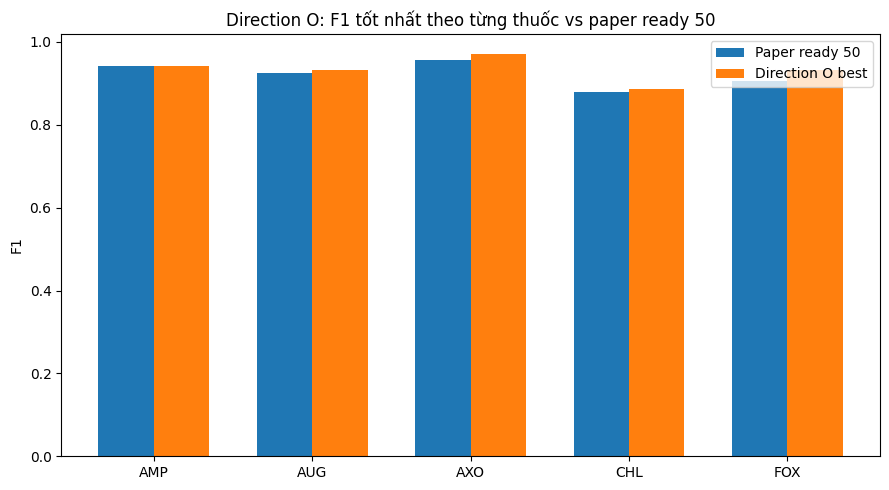

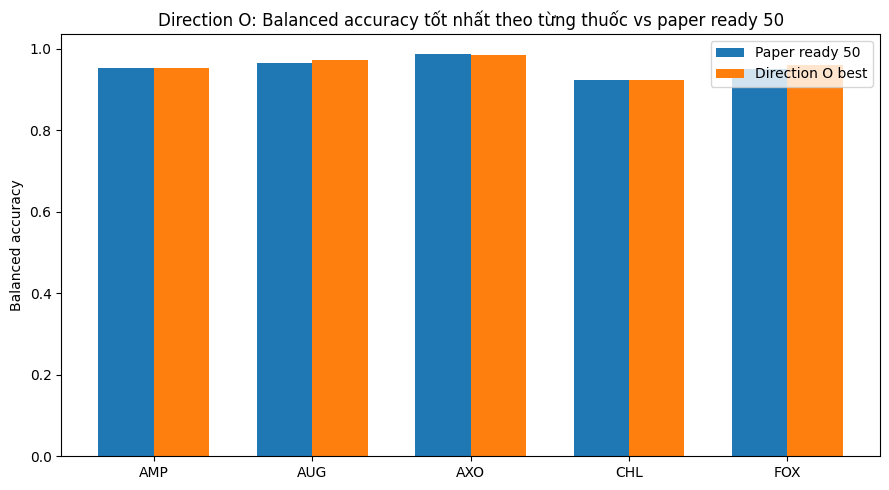

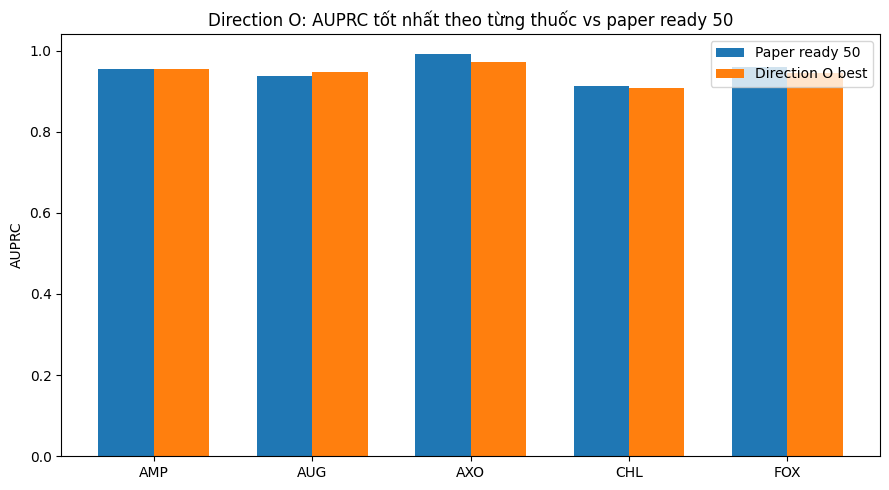

In [ ]:
plot_df = comparison.copy()
x = np.arange(len(plot_df))
width = 0.35

plt.figure(figsize=(9, 5))
plt.bar(x - width/2, plot_df["f1_mean_paper"], width, label="Paper ready 50")
plt.bar(x + width/2, plot_df["f1_mean_best"], width, label="Direction O best")
plt.xticks(x, plot_df["drug"])
plt.ylabel("F1")
plt.title("Direction O: F1 tốt nhất theo từng thuốc vs paper ready 50")
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "direction_O_f1_vs_paper.png", dpi=200)
plt.show()

plt.figure(figsize=(9, 5))
plt.bar(x - width/2, plot_df["balanced_accuracy_mean_paper"], width, label="Paper ready 50")
plt.bar(x + width/2, plot_df["balanced_accuracy_mean_best"], width, label="Direction O best")
plt.xticks(x, plot_df["drug"])
plt.ylabel("Balanced accuracy")
plt.title("Direction O: Balanced accuracy tốt nhất theo từng thuốc vs paper ready 50")
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "direction_O_balacc_vs_paper.png", dpi=200)
plt.show()

plt.figure(figsize=(9, 5))
plt.bar(x - width/2, plot_df["auprc_mean_paper"], width, label="Paper ready 50")
plt.bar(x + width/2, plot_df["auprc_mean_best"], width, label="Direction O best")
plt.xticks(x, plot_df["drug"])
plt.ylabel("AUPRC")
plt.title("Direction O: AUPRC tốt nhất theo từng thuốc vs paper ready 50")
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "direction_O_auprc_vs_paper.png", dpi=200)
plt.show()


In [ ]:

# Conclusion

lines = []
lines.append("# Direction O — Auto conclusion")
lines.append("")
lines.append("## 1. Mục tiêu")
lines.append("Direction O gom các module từ A–N để chọn cấu hình tối ưu riêng cho từng kháng sinh.")
lines.append("")
lines.append("## 2. Cấu hình tốt nhất theo từng thuốc")

for _, row in best_df.iterrows():
    lines.append(
        f"- {row['drug']}: best = {row['setting']} + {row['model']}; "
        f"F1 = {row['f1_mean']:.3f} ± {row['f1_std']:.3f}; "
        f"balanced accuracy = {row['balanced_accuracy_mean']:.3f} ± {row['balanced_accuracy_std']:.3f}; "
        f"AUPRC = {row['auprc_mean']:.3f} ± {row['auprc_std']:.3f}."
    )

lines.append("")
lines.append("## 3. So sánh với paper ready 50")
for _, row in comparison.iterrows():
    lines.append(
        f"- {row['drug']}: Direction O thay đổi F1 {row['delta_f1']:+.3f}, "
        f"balanced accuracy {row['delta_balanced_accuracy']:+.3f}, "
        f"AUPRC {row['delta_auprc']:+.3f} so với paper ready 50."
    )

lines.append("")
lines.append("## 4. Diễn giải")
lines.append("- Nếu các thuốc chọn setting khác nhau, điều đó ủng hộ giả thuyết drug-specific adaptive feature fusion.")
lines.append("- Nếu Direction O tăng F1/balanced accuracy/AUPRC ở một số thuốc, đây là bằng chứng cho thấy kết hợp module theo từng thuốc có thể cải thiện hiệu năng hơn pipeline cố định.")
lines.append("- Nếu paper ready 50 vẫn thắng ở một số thuốc, điều đó cho thấy bộ feature của bài báo đã rất mạnh cho thuốc đó.")

conclusion_text = "\n".join(lines)
print(conclusion_text)

with open(OUTPUT_DIR / "AUTO_CONCLUSION_DIRECTION_O.md", "w", encoding="utf-8") as f:
    f.write(conclusion_text)


# Direction O — Auto conclusion

## 1. Mục tiêu
Direction O gom các module từ A–N để chọn cấu hình tối ưu riêng cho từng kháng sinh.

## 2. Cấu hình tốt nhất theo từng thuốc
- AMP: best = paper_ready50 + XGB_weighted; F1 = 0.943 ± 0.024; balanced accuracy = 0.953 ± 0.022; AUPRC = 0.955 ± 0.019.
- AUG: best = accessory200_plus_gene_graph_embedding + LR_balanced; F1 = 0.932 ± 0.032; balanced accuracy = 0.972 ± 0.022; AUPRC = 0.947 ± 0.033.
- AXO: best = ensemble_top_50 + XGB_weighted; F1 = 0.971 ± 0.029; balanced accuracy = 0.985 ± 0.025; AUPRC = 0.971 ± 0.047.
- CHL: best = paper_ready50_plus_chi2_200 + LR_balanced; F1 = 0.886 ± 0.041; balanced accuracy = 0.923 ± 0.031; AUPRC = 0.907 ± 0.043.
- FOX: best = accessory200_plus_sample_graph + XGB_weighted; F1 = 0.932 ± 0.037; balanced accuracy = 0.959 ± 0.020; AUPRC = 0.945 ± 0.035.

## 3. So sánh với paper ready 50
- AMP: Direction O thay đổi F1 +0.000, balanced accuracy +0.000, AUPRC +0.000 so với paper ready 50.
- AUG: Direction O thay đ

In [ ]:

# =Antibiotic-aware interpretation
# Nối với nhóm thuốc/cơ chế kháng để giải thích vì sao mỗi thuốc chọn một module feature khác nhau

drug_metadata = [
    {
        "drug": "AMP",
        "drug_name": "Ampicillin",
        "drug_class": "penicillin",
        "broad_class": "beta_lactam",
        "mechanism": "inhibits bacterial cell wall synthesis",
        "common_resistance_mechanism": "beta-lactamase, altered PBPs, permeability/efflux",
        "has_beta_lactam": 1,
        "has_beta_lactamase_inhibitor": 0,
        "combination_drug": 0,
        "expected_feature_strategy": "marker-aware hybrid: paper ready50 + accessory genes"
    },
    {
        "drug": "AUG",
        "drug_name": "Amoxicillin + clavulanic acid",
        "drug_class": "penicillin + beta-lactamase inhibitor",
        "broad_class": "beta_lactam_combination",
        "mechanism": "cell wall synthesis inhibition plus beta-lactamase inhibition",
        "common_resistance_mechanism": "beta-lactamase/inhibitor response, altered PBPs, permeability",
        "has_beta_lactam": 1,
        "has_beta_lactamase_inhibitor": 1,
        "combination_drug": 1,
        "expected_feature_strategy": "paper ready50 may already capture strong markers"
    },
    {
        "drug": "AXO",
        "drug_name": "Ceftriaxone",
        "drug_class": "third-generation cephalosporin",
        "broad_class": "beta_lactam",
        "mechanism": "inhibits bacterial cell wall synthesis",
        "common_resistance_mechanism": "ESBL/AmpC beta-lactamase, plasmid-associated resistance",
        "has_beta_lactam": 1,
        "has_beta_lactamase_inhibitor": 0,
        "combination_drug": 0,
        "expected_feature_strategy": "paper ready50 + broader accessory genes"
    },
    {
        "drug": "CHL",
        "drug_name": "Chloramphenicol",
        "drug_class": "chloramphenicol class",
        "broad_class": "protein_synthesis_inhibitor",
        "mechanism": "inhibits bacterial protein synthesis at the 50S ribosomal subunit",
        "common_resistance_mechanism": "efflux such as floR, chloramphenicol acetyltransferase, mobile elements",
        "has_beta_lactam": 0,
        "has_beta_lactamase_inhibitor": 0,
        "combination_drug": 0,
        "expected_feature_strategy": "wider accessory genes, functional/efflux-related features"
    },
    {
        "drug": "FOX",
        "drug_name": "Cefoxitin",
        "drug_class": "cephamycin",
        "broad_class": "beta_lactam",
        "mechanism": "inhibits bacterial cell wall synthesis",
        "common_resistance_mechanism": "AmpC beta-lactamase, plasmid-associated resistance",
        "has_beta_lactam": 1,
        "has_beta_lactamase_inhibitor": 0,
        "combination_drug": 0,
        "expected_feature_strategy": "ensemble/accessory feature selection, marker-aware hybrid"
    },
]

drug_meta_df = pd.DataFrame(drug_metadata)

def classify_feature_module(setting):
    s = str(setting).lower()
    if "paper_ready50_plus" in s:
        return "marker_aware_hybrid"
    if s == "paper_ready50" or "paper_ready50" in s:
        return "paper_marker_only"
    if "ensemble" in s:
        return "ensemble_selection"
    if "functional" in s:
        return "functional_augmented"
    if "sample_graph" in s:
        return "sample_graph_augmented"
    if "gene_graph" in s:
        return "gene_graph_augmented"
    if "accessory" in s:
        return "accessory_selected"
    return "other"

antibiotic_analysis_df = comparison.merge(drug_meta_df, on="drug", how="left")
antibiotic_analysis_df["feature_module_type"] = antibiotic_analysis_df["setting_best"].apply(classify_feature_module)

cols_to_show = [
    "drug", "drug_name", "broad_class", "drug_class",
    "setting_best", "feature_module_type", "model_best",
    "f1_mean_best", "delta_f1",
    "balanced_accuracy_mean_best", "delta_balanced_accuracy",
    "auprc_mean_best", "delta_auprc",
    "common_resistance_mechanism",
    "expected_feature_strategy"
]

display(antibiotic_analysis_df[cols_to_show])

antibiotic_analysis_df.to_csv(OUTPUT_DIR / "direction_O_antibiotic_aware_interpretation.csv", index=False)

rules = [
    {
        "condition": "Thuốc beta-lactam, có marker kháng rõ như beta-lactamase",
        "recommended_starting_modules": "paper/known markers + accessory 200/500",
        "rationale": "AMP/AXO thường hưởng lợi từ marker-aware hybrid; AUG có thể chỉ cần paper ready50."
    },
    {
        "condition": "Cephalosporin/cephamycin hoặc liên quan plasmid/AmpC",
        "recommended_starting_modules": "marker-aware hybrid hoặc ensemble top 500",
        "rationale": "AXO và FOX thường cần feature rộng hơn hoặc ensemble selection."
    },
    {
        "condition": "Non-beta-lactam, cơ chế liên quan efflux/vận chuyển/mobile element",
        "recommended_starting_modules": "accessory 500 + functional/domain-like features + graph features nếu cần",
        "rationale": "CHL tốt hơn với accessory feature rộng, không chỉ paper ready50."
    },
    {
        "condition": "Thuốc mới chưa rõ cơ chế",
        "recommended_starting_modules": "ensemble feature selection + accessory 500 + threshold tuning",
        "rationale": "Ensemble selection là lựa chọn khởi đầu an toàn khi chưa biết marker rõ."
    },
    {
        "condition": "Dữ liệu lệch lớp mạnh",
        "recommended_starting_modules": "class weight / scale_pos_weight / threshold tuning",
        "rationale": "Ưu tiên F1, recall và AUPRC thay vì chỉ accuracy."
    },
]

rules_df = pd.DataFrame(rules)
display(rules_df)
rules_df.to_csv(OUTPUT_DIR / "feature_selection_rules_for_new_antibiotic.csv", index=False)

extra_lines = []
extra_lines.append("")
extra_lines.append("## 5. Antibiotic-aware interpretation")
for _, row in antibiotic_analysis_df.iterrows():
    extra_lines.append(
        f"- {row['drug']} ({row['drug_class']}): best module = {row['setting_best']}; "
        f"module type = {row['feature_module_type']}; delta F1 = {row['delta_f1']:+.3f}. "
        f"Expected strategy: {row['expected_feature_strategy']}."
    )

extra_text = "\n".join(extra_lines)
print(extra_text)

with open(OUTPUT_DIR / "AUTO_CONCLUSION_DIRECTION_O.md", "a", encoding="utf-8") as f:
    f.write(extra_text)


,drug,drug_name,broad_class,drug_class,setting_best,feature_module_type,model_best,f1_mean_best,delta_f1,balanced_accuracy_mean_best,delta_balanced_accuracy,auprc_mean_best,delta_auprc,common_resistance_mechanism,expected_feature_strategy
0,AMP,Ampicillin,beta_lactam,penicillin,paper_ready50,paper_marker_only,XGB_weighted,0.942607,0.000000,0.952938,0.000000,0.955302,0.000000,"beta-lactamase, altered PBPs, permeability/efflux",marker-aware hybrid: paper ready50 + accessory...
1,AUG,Amoxicillin + clavulanic acid,beta_lactam_combination,penicillin + beta-lactamase inhibitor,accessory200_plus_gene_graph_embedding,gene_graph_augmented,LR_balanced,0.932089,0.006165,0.972018,0.006900,0.946669,0.009390,"beta-lactamase/inhibitor response, altered PBP...",paper ready50 may already capture strong markers
2,AXO,Ceftriaxone,beta_lactam,third-generation cephalosporin,ensemble_top_50,ensemble_selection,XGB_weighted,0.971116,0.014494,0.984805,-0.002208,0.971207,-0.020378,"ESBL/AmpC beta-lactamase, plasmid-associated r...",paper ready50 + broader accessory genes
3,CHL,Chloramphenicol,protein_synthesis_inhibitor,chloramphenicol class,paper_ready50_plus_chi2_200,marker_aware_hybrid,LR_balanced,0.885585,0.006523,0.923455,-0.000804,0.906984,-0.006027,"efflux such as floR, chloramphenicol acetyltra...","wider accessory genes, functional/efflux-relat..."
4,FOX,Cefoxitin,beta_lactam,cephamycin,accessory200_plus_sample_graph,sample_graph_augmented,XGB_weighted,0.932101,0.027463,0.958896,0.008506,0.944817,-0.014503,"AmpC beta-lactamase, plasmid-associated resist...","ensemble/accessory feature selection, marker-a..."


,condition,recommended_starting_modules,rationale
0,"Thuốc beta-lactam, có marker kháng rõ như beta...",paper/known markers + accessory 200/500,AMP/AXO thường hưởng lợi từ marker-aware hybri...
1,Cephalosporin/cephamycin hoặc liên quan plasmi...,marker-aware hybrid hoặc ensemble top 500,AXO và FOX thường cần feature rộng hơn hoặc en...
2,"Non-beta-lactam, cơ chế liên quan efflux/vận c...",accessory 500 + functional/domain-like feature...,"CHL tốt hơn với accessory feature rộng, không ..."
3,Thuốc mới chưa rõ cơ chế,ensemble feature selection + accessory 500 + t...,Ensemble selection là lựa chọn khởi đầu an toà...
4,Dữ liệu lệch lớp mạnh,class weight / scale_pos_weight / threshold tu...,"Ưu tiên F1, recall và AUPRC thay vì chỉ accuracy."



## 5. Antibiotic-aware interpretation
- AMP (penicillin): best module = paper_ready50; module type = paper_marker_only; delta F1 = +0.000. Expected strategy: marker-aware hybrid: paper ready50 + accessory genes.
- AUG (penicillin + beta-lactamase inhibitor): best module = accessory200_plus_gene_graph_embedding; module type = gene_graph_augmented; delta F1 = +0.006. Expected strategy: paper ready50 may already capture strong markers.
- AXO (third-generation cephalosporin): best module = ensemble_top_50; module type = ensemble_selection; delta F1 = +0.014. Expected strategy: paper ready50 + broader accessory genes.
- CHL (chloramphenicol class): best module = paper_ready50_plus_chi2_200; module type = marker_aware_hybrid; delta F1 = +0.007. Expected strategy: wider accessory genes, functional/efflux-related features.
- FOX (cephamycin): best module = accessory200_plus_sample_graph; module type = sample_graph_augmented; delta F1 = +0.027. Expected strategy: ensemble/accessory feature sel

In [ ]:

# zip

zip_path = BASE_DIR / "salmonella_direction_O_outputs.zip"
if zip_path.exists():
    zip_path.unlink()

shutil.make_archive(str(zip_path).replace(".zip", ""), "zip", OUTPUT_DIR)

print("Đã lưu kết quả tại:", OUTPUT_DIR)
print("File zip:", zip_path)


Đã lưu kết quả tại: /content/salmonella_direction_O_adaptive_fusion/outputs
File zip: /content/salmonella_direction_O_adaptive_fusion/salmonella_direction_O_outputs.zip
